## **5.1 합성곱 신경망**

- 역전파: 순전파 과정에 따라 계산된 오차 정보가 신경망의 모든 노드(출력층->은닉층->입력층)로 전송.
- 이런 계산 과정 복잡하고 많은 자원 요구
- 해결 방법: 합성곱 신경망

### **5.1.1 합성곱층의 필요성**
합성곱 신경망은 이미지나 영상을 처리하는 데 유용함.

[예시] 3X3 흑백 이미지

이미지 분석은 왼쪽과 같은 3X3 배열을 오른쪽과 같이 flattening해서 각 픽셀에 가중치를 곱하여 은닉층으로 전달한다. 하지만 이미지를 펼쳐서 분석하면 데이터의 공간적 구조를 무시하게 되는데, 이것을 방지하기 위해 도입된 것이 합성곱층이다.

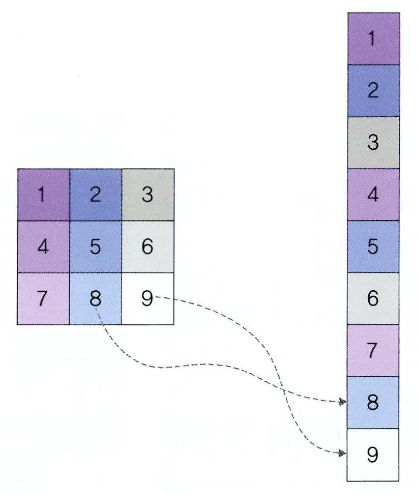

### **5.1.2 합성곱 신경망 구조**
합성곱 신경망은 음성 인식이나 이미지/영상 인식에서 주로 사용되는 신경망. 다차원 배열 데이터를 처리하도록 구성되어 컬러 이미지 같은 다차원 배열 처리에 특화되어 있으며, 계층 다섯 개로 구성된다.
1. 입력층
2. 합성곱층
3. 풀링층
4. 완전연결층
5. 출력층

합성곱 신경망은 합성곱층과 풀링층을 거치면서 입력 이미지의 주요 특성 벡터를 추출한다. 추출된 주요 특성 벡터들은 완전연결층을 거치면서 1차원 벡터로 변환되며, 마지막으로 출력층에서 활성화 함수인 소프트맥스 함수를 사용하여 최종 결과가 출력된다.

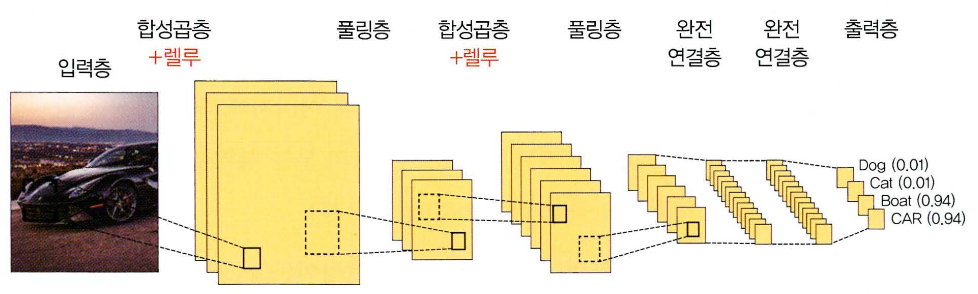

#### 입력층
입력층은 입력 이미지 데이터가 최초로 거치게 되는 계층. 이미지는 단순 1차원 데이터가 아닌 높이, 너비, 채널의 값을 갖는 3차원 데이터다. 이때 채널은 이미지가 grayscale이면 1값을 가지며, RGB이면 3값을 갖는다.

#### 합성곱층
합성곱층은 입력 데이터에서 특성을 추출하는 역할을 수행. 특성 추출은 입력 이미지가 들어왔을 때 특성을 감지하기 위해 커널이나 필터를 사용한다. 커널/필터는 이미지의 모든 영역을 훑으면서 특성을 추철하게 되는데, 이렇게 추출된 결과물이 특성 맵이다.

커널은 3x3, 5x5크기로 적용되는 것이 일반적이며, stride는 지정된 간격에 따라 순차적으로 이동. 이미지 크기가 (6,6,1)이고 3x3 크기의 커널/필터가 스트라이드 1 간격으로 이동하면서 합성곱 연산을 수행하면 (4,4,1) 크기로 줄어든다.

컬러 이미지의 합성곱은 필터 채널이 3이라는 것과 RGB 각각에 서로 다른 가중치로 합성곱을 적용한 후 더해 준다는 점에서 차이점이 있다. 필터 채널이 3이라고 해서 필터 개수도 세 개라고 오해할 수 있지만, 실제로는 필터 개수가 한 개라는 점에 주의해야 함.

필터가 두 개 이상이면 필터 각각은 특성 추출 결과의 채널이 된다.

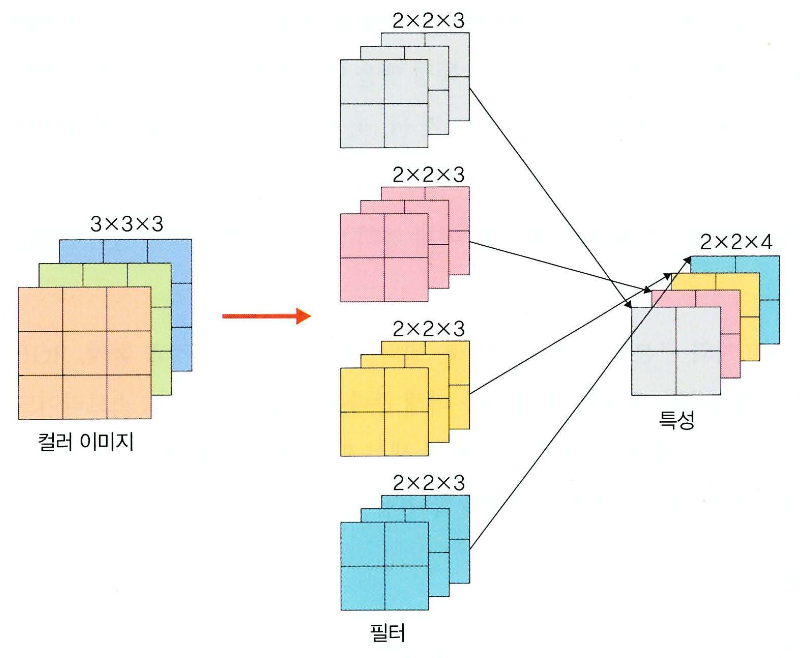

[합성곱층]
- 입력 데이터: W1 x H1 x D1(W1:가로 ,H1:세로, D1:채널 또는 깊이)
- 하이퍼파라미터
  - 필터 개수: K
  - 필터 크기: F
  - 스트라이드: S
  - 패딩: P
- 출력 데이터
  - W2 = (W1-F+2P)/S + 1
  - H2 = (H1-F+2P)/S + 1
  - D2 = K

#### 풀링층
풀링층은 합성곱층과 유사하게 특성 맵의 차원을 다운 샘플링하여 연산량을 감소시키고, 주요한 특성 벡터를 추출하여 학습을 효과적으로 할 수 있게 함.

[풀링 연산]
- 최대 풀링: 대상 영역에서 최댓값을 추출
- 평균 풀링: 대상 영역에서 평균을 반환

평균 풀링은 각 커널 값을 평균화시켜 중요한 가중치를 갖는 값의 특성이 희미해질 수 있기 때문에 대부분의 연산에는 최대 풀링이 사용된다.

#### 완전연결층
합성곱층과 풀링층을 거치면서 차원이 축소된 특성 맵은 최종적으로 완전연결층으로 전달된다. 이 과정에서 이미지는 3차원 벡터에서 1차원 벡터로 펼쳐지게 된다.

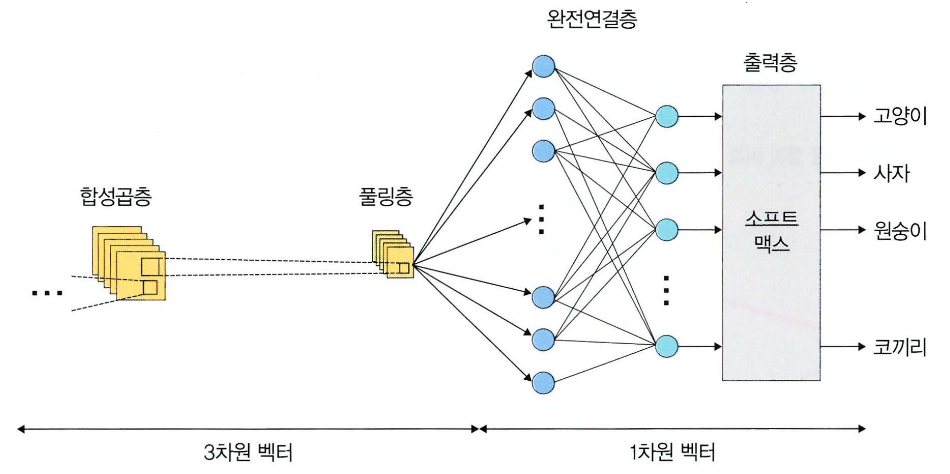

#### 출력층
출력층에서는 소프트맥스 활성화 함수가 사용되는데, 입력받은 값을 0~1 사이의 값으로 출력한다. 따라서 마지막 출력층의 소프트맥스 함수를 사용하여 이미지가 각 레이블에 속할 확률 값이 출력되며, 이때 가장 높은 확률 값을 갖는 레이블이 최종 값으로 선정된다.

### **5.1.3 1D, 2D, 3D 합성곱**
- 합성곱은 이동하는 방향의 수와 출력 형태에 따라 1D, 2D, 3D로 분류할 수 있음

#### 1D 합성곱
1D 합성곱은 필터가 시간을 축으로 좌우로만 이동할 수 있는 합성곱. 따라서 입력 W과 필터 k에 대한 출력은 W가 된다. 그래프 곡선을 완화할 때 많이 사용된다.

[예시]
- 입력: [1,1,1,1,1]
- 필터: [0.25,0.5,0.25]
- 출력: [1,1,1]

#### 2D 합성곱
2D 합성곱은 필터가 방향 두 개로 움직이는 형태다.
- 입력: (W, H)
- 필터: (k, k)
- 출력: (W, H)

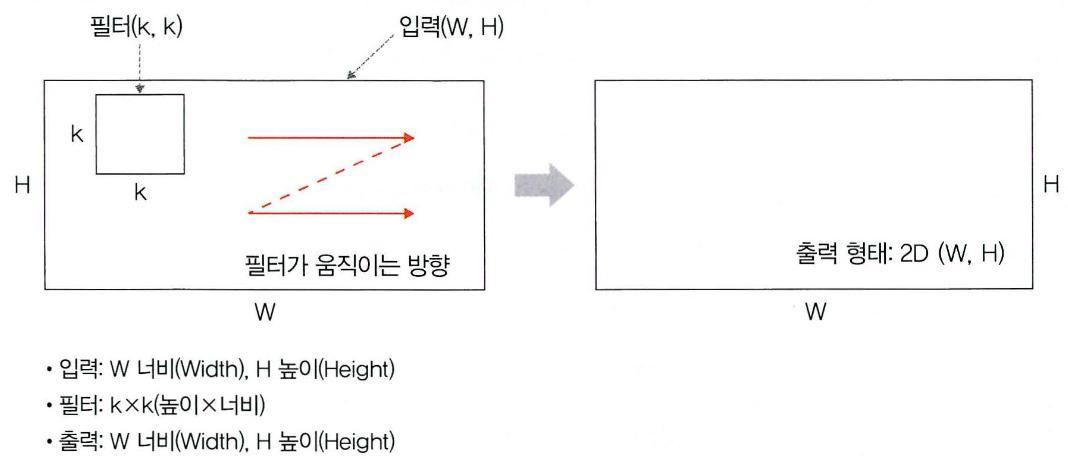

#### 3D 합성곱
3D 합성곱은 필터가 움직이는 방향이 세 개 있다.
- 입력: (W, H, L)
- 필터: (k, k, d)
- 출력: (W, H, L)

출력은 3D형태이며 d<L유지하는 것 중요.

#### 3D 입력을 갖는 2D 합성곱
입력이 (224x224x3, 112x112x32)와 같은 3D 형태임에도 출력 형태가 3D가 아닌 2D 행렬을 취하는 것이 3D 입력을 갖는 2D 합성곱이다. 이것은 필터에 대한 길이가 입력 채널의 길이와 같아야 하기 때문에 이런 합성곱 형태가 만들어진다.
- 입력: (W, H, L)
- 필터: (k, k, L)
- 출력: (W, H)

필터는 두 방향으로 움직이며 출력 형태는 2D 행렬이 된다. 이 대표적 사례로는 LeNet-5, VGG가 있다.

#### 1x1 합성곱
1x1 합성곱은 3D형태로 입력된다. 즉, 입력 (W, H, L)에 필터 (1, 1, L)를 적용하면 출력은 (W, H)가 된다. 1x1 합성곱에서 채널 수를 조정해서 연산량이 감소되는 효과가 있으며, 대표적 사례로는 GoogLeNet이 있다.